In [12]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

import seaborn as sns
from helper_functions_objs import *

## Pre-process the objective values

In [13]:
obj_names = ['REL', 'RF', 'INPC', 'PFC', 'WCC']
util_abbrevs = ['W', 'D', 'F']

# append obj names to util_abbrevs
objs_utils = [f'{obj}_{util}' for util in util_abbrevs for obj in obj_names]
objs_regional =  [f'{obj}_R' for obj in obj_names]
objs_W = [f'{obj}_W' for obj in obj_names]
objs_D = [f'{obj}_D' for obj in obj_names]
objs_F = [f'{obj}_F' for obj in obj_names]

In [14]:
obj_mode = 'avg'

# read in objectives
objs_truncated_base_allutils = pd.read_csv(f'objectives_dvs_nd/objectives_base_{obj_mode}_nd.csv', index_col=False, header=None)
objs_truncated_base_allutils.columns = objs_utils
objs_truncated_IU_allutils = pd.read_csv(f'objectives_dvs_nd/objectives_IU_{obj_mode}_nd.csv', index_col=False, header=None)
objs_truncated_IU_allutils.columns = objs_utils

# split objectives by utility
objs_W_IU = objs_truncated_IU_allutils[[f'{obj}_W' for obj in obj_names]]
objs_D_IU = objs_truncated_IU_allutils[[f'{obj}_D' for obj in obj_names]]
objs_F_IU = objs_truncated_IU_allutils[[f'{obj}_F' for obj in obj_names]]

objs_W_base = objs_truncated_base_allutils[[f'{obj}_W' for obj in obj_names]]
objs_D_base = objs_truncated_base_allutils[[f'{obj}_D' for obj in obj_names]]
objs_F_base = objs_truncated_base_allutils[[f'{obj}_F' for obj in obj_names]]

# find regional minimax solutions
objs_base_reg = find_regional_minimax(objs_truncated_base_allutils, obj_names)
objs_IU_reg = find_regional_minimax(objs_truncated_IU_allutils, obj_names)

# save the results
objs_base_reg.to_csv(f'objectives_dvs_nd/objectives_base_{obj_mode}_nd_regional.csv', index=False)
objs_IU_reg.to_csv(f'objectives_dvs_nd/objectives_IU_{obj_mode}_nd_regional.csv', index=False)

In [15]:
# import reference sets 
refset_IU = pd.read_csv(f'objectives_dvs_nd/refset_IU_p10_truncated_extremes.csv', index_col=False, header=None)
refset_IU.columns = obj_names
refset_base = pd.read_csv(f'objectives_dvs_nd/refset_base_avg_truncated_extremes.csv', index_col=False, header=0)
refset_base.columns = obj_names

dvs_IU = np.loadtxt(f'objectives_dvs_nd/dvs_IU_nd_truncated_extremes.csv', delimiter=",")
dvs_base = np.loadtxt(f'objectives_dvs_nd/dvs_base_nd_truncated_extremes.csv', delimiter=",")

In [16]:
# find index in refset_IU where INPC is less than or equal to the INPC of refset_base 
refset_IU_filtered = refset_IU[refset_IU['INPC'] <= refset_base['INPC'].max()]
# find rows where INPC in refset_IU is less than or equal to max INPC in refset_base
refset_IU_filtered_index = refset_IU.index[refset_IU['INPC'] <= refset_base['INPC'].max()].tolist()
dvs_IU_filtered = dvs_IU[refset_IU_filtered_index, :]

# save the filtered reference set and dvs
refset_IU_filtered.to_csv(f'objectives_dvs_nd/refset_IU_p10_truncated_extremes_filtered.csv', index=False)
np.savetxt(f'objectives_dvs_nd/dvs_IU_nd_truncated_extremes_filtered.csv', dvs_IU_filtered, delimiter=",")

### Plot 3D scatter plot of objective tradeoffs to compare base and IU cases

In [17]:
# function to turn two colors into a colormap
def two_color_cmap(color1, color2, num_points=100, reverse=False):
    from matplotlib.colors import LinearSegmentedColormap
    cmap = LinearSegmentedColormap.from_list('custom_cmap', [color1, color2], N=num_points)
    if reverse:
        cmap = LinearSegmentedColormap.from_list('custom_cmap', [color2, color1], N=num_points)
    # normalize to get colors
    return cmap

In [ ]:
def plot_scatter(ax, utility_name, obj_mode, objs_df1, objs_df2, cmap_color1, cmap_color2, label1, label2, marker1, marker2, norm_rel):
    util_abbrev = utility_name[0]
    # colormap uses reliability as color
    cm1 = two_color_cmap(cmap_color1[0], cmap_color1[1], num_points=500, reverse=False)
    cm2 = two_color_cmap(cmap_color2[0], cmap_color2[1], num_points=500, reverse=False)

    cmap1 = cm1(norm_rel(objs_df1[f'RF_{util_abbrev}']))
    cmap2 = cm2(norm_rel(objs_df2[f'RF_{util_abbrev}']))
    min_PFC = min(objs_df1[f'PFC_{util_abbrev}'].min(), objs_df2[f'PFC_{util_abbrev}'].min())
    max_PFC = max(objs_df1[f'PFC_{util_abbrev}'].max(), objs_df2[f'PFC_{util_abbrev}'].max())
    # normalize the PFC values to use as size of points
    norm_rf1 = (objs_df1[f'PFC_{util_abbrev}'] - min_PFC) /  ((max_PFC - min_PFC))
    norm_rf2 = (objs_df2[f'PFC_{util_abbrev}'] - min_PFC) /  ((max_PFC - min_PFC))

    # use RF as size of points
    ax.scatter(objs_df1[f'WCC_{util_abbrev}'], objs_df1[f'INPC_{util_abbrev}'], objs_df1[f'REL_{util_abbrev}'], 
               label=label1, alpha=0.75, c=cmap1, marker=marker1, edgecolor='#055253', s=(1-norm_rf1)*45, depthshade=False, zorder=2)

    ax.scatter(objs_df2[f'WCC_{util_abbrev}'], objs_df2[f'INPC_{util_abbrev}'], objs_df2[f'REL_{util_abbrev}'],
               label=label2, alpha=0.75, c=cmap2, marker=marker2, edgecolor='#DA7635', s=(1-norm_rf2)*45, depthshade=False, zorder=1)

    # plot the ideal point 
    ax.scatter(0.0, 0.0, 1.0, label='Ideal Point', c='black', marker='*', s=250)

    ax.set_ylabel(r'$\longleftarrow$ Infrastructure' + r' NPC (\$mil)', size=12)
    ax.set_xlabel(r' $\longleftarrow$  Worst-Case Cost', size=12)
    ax.set_zlabel(r'Reliability $\longrightarrow$', size=12)

    #ax.set_xticks([0.25, 0.5, 0.75, 1.0])
    #ax.set_xticklabels([1.0, 0.75, 0.5, 0.25])

    ax.set_title(f'{utility_name} under {obj_mode} conditions', fontsize=14, pad=0, y=0.99)

    # rotate the axes
    ax.view_init(elev=20., azim=-65)

In [19]:
utility = "Regional"
util_abbrev = 'R'
objs_base_util = objs_base_reg
objs_IU_util = objs_IU_reg

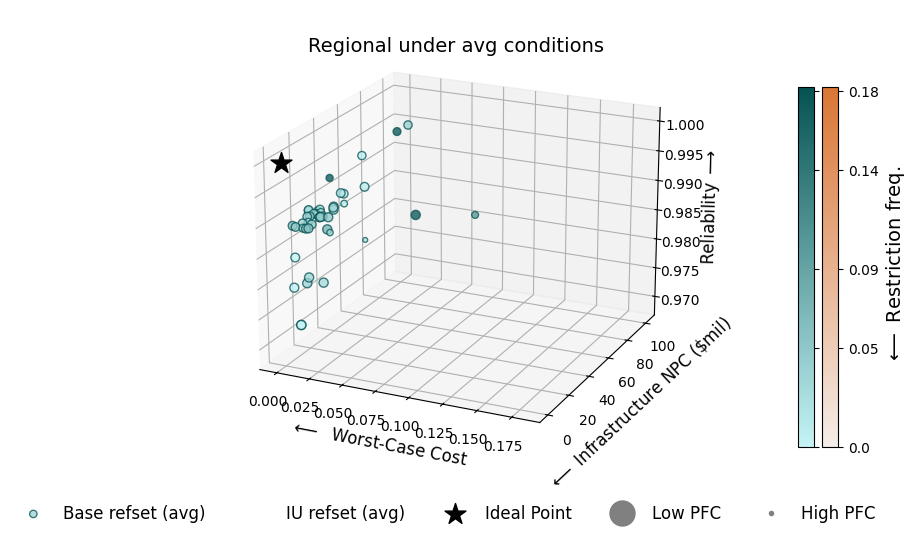

In [20]:
colormap_objmode_dict = {'IU': ["#F5EDE8", "#DA7635"], 'base': ["#C4F4F5", "#055253"]}
fig, axes = plt.subplots(1, 1, subplot_kw={'projection': '3d'}, figsize=(8, 6))

cbar_col = f'WCC_{util_abbrev}'

cbar_norm = plt.Normalize(vmin=min(objs_base_util[cbar_col].min(), objs_IU_util[cbar_col].min()), 
                        vmax=max(objs_base_util[cbar_col].max(), objs_IU_util[cbar_col].max()))
'''
cbar_norm = plt.Normalize(vmin=0.0, vmax=0.5)
'''
# create scatter plots for each utility
plot_scatter(axes, utility, obj_mode, objs_base_util, objs_IU_util,  
            colormap_objmode_dict['base'], colormap_objmode_dict['IU'], 
            f"Base refset ({obj_mode})", f"IU refset ({obj_mode})", 'o', 'o', cbar_norm)

# insert a colorbar outside the plots
cbar_ax_base = fig.add_axes([0.94, 0.15, 0.02, 0.6])
cbar_ax_IU = fig.add_axes([0.97, 0.15, 0.02, 0.6])

cm1 = two_color_cmap(colormap_objmode_dict['base'][0], colormap_objmode_dict['base'][1], num_points=500, reverse=False)
cm2 = two_color_cmap(colormap_objmode_dict['IU'][0], colormap_objmode_dict['IU'][1], num_points=500, reverse=False)

# create colorbars for each colormap
sm_base = plt.cm.ScalarMappable(cmap=cm1, norm=cbar_norm)
sm_base._A = []  # empty array for the scalar mappable
sm_IU = plt.cm.ScalarMappable(cmap=cm2, norm=cbar_norm)
sm_IU._A = []  # empty array for the scalar mappable
cbar_base = fig.colorbar(sm_base, cax=cbar_ax_base)
cbar_IU = fig.colorbar(sm_IU, cax=cbar_ax_IU)

# set ticks and label on colorbar

cbar_yticks = np.linspace(min(objs_base_util[cbar_col].min(), objs_IU_util[cbar_col].min(), 1.0), 
                            max(objs_base_util[cbar_col].max(), objs_IU_util[cbar_col].max()), 5)

#cbar_yticks = np.linspace(0.0, 0.16, 4)
# limit number of decimal places to 2
cbar_yticks = [round(tick, 2) for tick in cbar_yticks]
cbar_ax_base.set_yticks(cbar_yticks)
cbar_ax_IU.set_yticks(cbar_yticks)
cbar_ax_base.set_yticklabels([])
cbar_ax_IU.set_yticklabels(cbar_yticks)
cbar_IU.set_label(r' $\longleftarrow$ Restriction freq.', size=14)

# include legend on bottom of plots
handles, labels = axes.get_legend_handles_labels()
# add two more legend entries to show smaller and larger point sizes
handles.append(plt.Line2D([0], [0], marker='o', color='w', label='Low PFC', markerfacecolor='gray', markersize=20))
handles.append(plt.Line2D([0], [0], marker='o', color='w', label='High PFC', markerfacecolor='gray', markersize=5))
labels.append('Low PFC')
labels.append('High PFC')
# create legend with 2 rows
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=12, frameon=False, bbox_to_anchor=(0.5, -0.))
plt.subplots_adjust(bottom=0.1)
#plt.savefig(f'figures/scatter3d_objs{util_abbrev}_{obj_mode}_nd.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Plot the parallel coordinate plots of the regional tradeoff set

In [21]:
from matplotlib import colormaps, cm
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from pandas.plotting import parallel_coordinates
from parallel_plot_functions import *

In [35]:
objs_base_util_cat = objs_base_reg.copy()
objs_IU_util_cat = objs_IU_reg.copy()
utility_parallel = "Regional"

objs_base_util_cat['Category'] = f"Base"
objs_IU_util_cat['Category'] = f"IU"

# concatenate the two dataframes
objs_combined = pd.concat([objs_base_util_cat], ignore_index=True)
#objs_combined = objs_base_util_cat
color_dict_coop = {'Base': "#588157", 'IU': "#F5A36D"}

# setup figure specifications and dimensions
figsize = (9,4)
fontsize = 14
#axis_mins = objs_combined.min().values[:-1] - (objs_combined.min().values[:-1] * 0.05)
#axis_maxs = objs_combined.max().values[:-1] + (objs_combined.max().values[:-1] * 0.05)

# cap axis mins and maxs to reasonable values
#axis_mins = np.maximum(axis_mins, 0.0)
#axis_maxs[0] = min(axis_maxs[0], 1.0)

axis_mins = [0.97, 0.0, 0.0,0.0,0.0]
axis_maxs = [1.0, 0.3, 100.0, 0.2, 0.2]
# get the axis labels 
axis_labels = objs_combined.columns.tolist()[:-1]

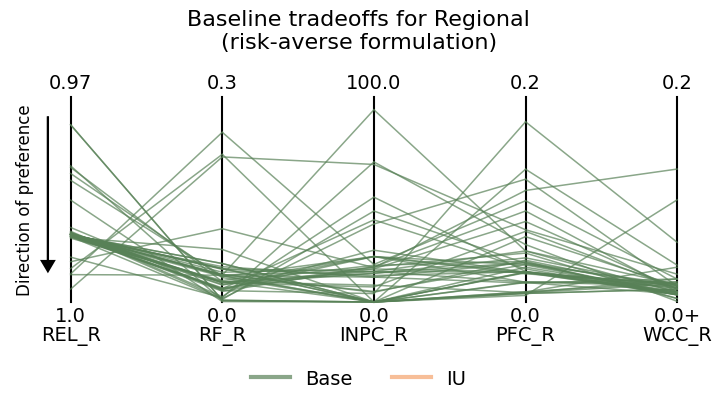

In [36]:
### create figure
fig, ax = plt.subplots(1,1,figsize=figsize, gridspec_kw={'hspace':0.1, 'wspace':0.1})
custom_parallel_coordinates(fig, ax, objs_combined, columns_axes=axis_labels, 
                                axis_labels=axis_labels, 
                                ideal_direction='bottom',
                                alpha_base=0.7, lw_base=1.1, fontsize=fontsize,
                                minmaxs=['max','min','min','min','min'], 
                                colorbar_ticks_continuous=range(0,1,5),
                                color_by_categorical = 'Category', 
                                color_dict_categorical=color_dict_coop,
                                axis_mins=axis_mins, axis_maxs=axis_maxs) 
#ax.set_title(f'IU and Base reference set tradeoffs', fontsize=fontsize+2, pad=20)
#plt.savefig(f'figures/parallel_IU_refset.png', dpi=300, bbox_inches='tight')
ax.set_title(f'Baseline tradeoffs for {utility_parallel}\n(risk-averse formulation)', fontsize=fontsize+2, pad=20)
plt.savefig(f'figures/parallel_refset_{obj_mode}_{utility_parallel[0]}_nd.pdf', dpi=300, bbox_inches='tight')